In [1]:
import os
import gc
import sys

import tensorflow as tf

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from srlib.deep_learning.esrgan import ESRGAN
from srlib.dataset.loading import load_esrgan_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.constants import (
    CLASS_LABELS_PATH,
    ESRGAN_BATCH_SIZE,
    ESRGAN_GROWTH_CHANNELS,
    ESRGAN_PATCH_SIZE,
    ESRGAN_RRDB_BLOCKS,
    ESRGAN_SCALE_FACTOR,
    ESRGAN_STRIDE,
    HR_ROOT,
    LR_ROOT,
)

c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\bgmanuel\anaconda3\envs\py310\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

In [2]:
# Enable memory growth (prevents full pre-allocation)
for gpu in tf.config.experimental.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"Memory growth not set: {e}")

In [3]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_esrgan_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=ESRGAN_PATCH_SIZE,
    stride=ESRGAN_STRIDE,
    scale_factor=ESRGAN_SCALE_FACTOR,
)


 ESRGAN dataset | patch 32, stride 32, x2
  images    358 indexed -> 358 kept -> 289 train / 33 val / 36 test


  patches   18,496 train / 2,112 val / 2,304 test   of 32 x 32 x 3
  memory    1.11 GB
  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]


  done in 5.0s



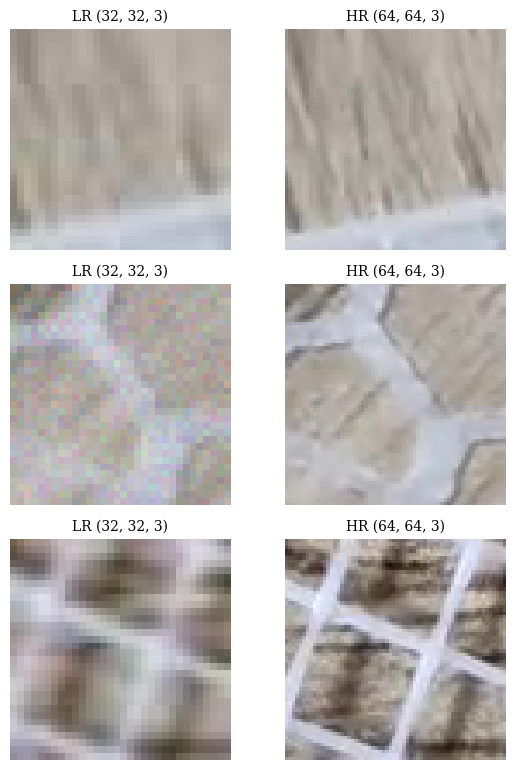

In [4]:
# What the model is actually fed: the LR patch and the HR patch it must
# reconstruct, whose side is ESRGAN_SCALE_FACTOR times larger.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [5]:
# The test dataset is also defined here (only for later evaluation)
# Normalised to [-1,1] to match what training used
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, Y_test)).batch(ESRGAN_BATCH_SIZE)
test_dataset = test_dataset.map(lambda x,y: (x*2.0 - 1.0, y*2.0 - 1.0), num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

In [6]:
model = ESRGAN()

model.setup_model(
    scale_factor=ESRGAN_SCALE_FACTOR, 
    growth_channels=ESRGAN_GROWTH_CHANNELS, 
    num_rrdb_blocks=ESRGAN_RRDB_BLOCKS, 
    input_shape=X_train.shape[1:],
    output_shape=Y_train.shape[1:],
    from_trained=False
)

GENERATOR SUMMARY
Model: "Generator"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 lr_input (InputLayer)          [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 initial_conv (Conv2D)          (None, 32, 32, 64)   1792        ['lr_input[0][0]']               
                                                                                                  
 rrdb_0_dense1_conv1 (Conv2D)   (None, 32, 32, 8)    4616        ['initial_conv[0][0]']           
                                                                                                  
 rrdb_0_dense1_concat1 (Concate  (None, 32, 32, 72)  0           ['initial_conv[0][0]',           
 nate)                                                            'rrdb_

In [7]:
# Train ESRGAN and capture callbacks for metrics. The preview grids are
# staged outside the run directory and moved into it when the model is
# saved, so an interrupted run does not leave an incomplete run behind.
epoch_losses, time_cb, mem_cb = model.fit(
    X_train=X_train, 
    Y_train=Y_train, 
    X_val=X_val, 
    Y_val=Y_val,
    epochs=10, 
    batch_size=ESRGAN_BATCH_SIZE,
)

Training on GPU: ['/physical_device:GPU:0']
Epoch 1/10


ResourceExhaustedError: Exception encountered when calling layer "self_attention_upsample_0" "                 f"(type SelfAttention).

{{function_node __wrapped__Softmax_device_/job:localhost/replica:0/task:0/device:GPU:0}} OOM when allocating tensor with shape[16,4096,4096] and type float on /job:localhost/replica:0/task:0/device:GPU:0 by allocator GPU_0_bfc [Op:Softmax]

Call arguments received by layer "self_attention_upsample_0" "                 f"(type SelfAttention):
  • x=tf.Tensor(shape=(16, 64, 64, 64), dtype=float32)

In [ ]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

In [9]:
# Evaluates the run, saves generator and discriminator, the metrics and the
# staged preview grids, all under one timestamp.
timestamp, run_dir, metrics = model.evaluate_and_save(
    test_dataset, epoch_losses, time_cb, mem_cb,
)

Evaluating model on test dataset...
Evaluation Results:
  Average PSNR: 28.8198
  Average SSIM: 0.8091
  Average G Loss: 17.5548
